In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from google.colab import drive

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [ ]:
DATA_DIR = "/content"  # change if needed

train_data = np.load(f"{DATA_DIR}/quickdraw_train.npz")
test_data  = np.load(f"{DATA_DIR}/quickdraw_test.npz")

X_full = train_data["x_train"]
y_full = train_data["y_train"]
class_names = train_data["class_names"]

X_test = test_data["test_images"]

print("Train:", X_full.shape, y_full.shape)
print("Test:", X_test.shape)
print("Classes:", len(class_names))

Train: (60000, 784) (60000,)
Test: (15000, 784)
Classes: 15


In [ ]:
def preprocess(X):
    if X.ndim == 3:
        X = X.reshape(X.shape[0], -1)
    X = X.astype(np.float32)
    if X.max() > 1:
        X /= 255.0
    return X

X_full = preprocess(X_full)
X_test = preprocess(X_test)
y_full = y_full.astype(np.int64)

print("After preprocessing:", X_full.shape)
print("Pixel range:", X_full.min(), X_full.max())

After preprocessing: (60000, 784)
Pixel range: 0.0 1.0


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=0.15,
    random_state=42,
    stratify=y_full
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)

Train: (51000, 784)
Val: (9000, 784)


In [ ]:
class QuickDrawDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.from_numpy(X)
        self.y = None if y is None else torch.from_numpy(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is None:
            return self.X[idx]
        return self.X[idx], self.y[idx]

batch_size = 256

train_loader = DataLoader(QuickDrawDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(QuickDrawDataset(X_val, y_val), batch_size=batch_size)
test_loader  = DataLoader(QuickDrawDataset(X_test, None), batch_size=batch_size)

In [ ]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=(2048,), num_classes=15, dropout=0.25):
        super().__init__()

        layers = []
        input_dim = 784

        for h in hidden_sizes:
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            input_dim = h

        layers.append(nn.Linear(input_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

num_classes = len(class_names)

HIDDEN_SIZES = (2048,)  # Wide & shallow

model = MLP(hidden_sizes=HIDDEN_SIZES, num_classes=num_classes).to(device)

print("Parameters:", count_params(model))

Parameters: 1642511


In [ ]:
@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    return correct / total

def train_model(model, epochs=40, lr=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    history = {"train_acc": [], "val_acc": []}

    for epoch in range(1, epochs+1):
        model.train()

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            optimizer.step()

        train_acc = accuracy(model, train_loader)
        val_acc = accuracy(model, val_loader)

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

    return history

history = train_model(model, epochs=40)

Epoch 01 | Train Acc: 74.36% | Val Acc: 70.87%
Epoch 02 | Train Acc: 78.70% | Val Acc: 72.44%
Epoch 03 | Train Acc: 82.89% | Val Acc: 73.90%
Epoch 04 | Train Acc: 84.59% | Val Acc: 74.39%
Epoch 05 | Train Acc: 89.78% | Val Acc: 76.41%
Epoch 06 | Train Acc: 90.44% | Val Acc: 75.41%
Epoch 07 | Train Acc: 92.40% | Val Acc: 75.73%
Epoch 08 | Train Acc: 94.81% | Val Acc: 76.91%
Epoch 09 | Train Acc: 94.36% | Val Acc: 75.46%
Epoch 10 | Train Acc: 95.47% | Val Acc: 74.86%
Epoch 11 | Train Acc: 96.38% | Val Acc: 75.84%
Epoch 12 | Train Acc: 97.19% | Val Acc: 76.20%
Epoch 13 | Train Acc: 97.34% | Val Acc: 75.84%
Epoch 14 | Train Acc: 96.88% | Val Acc: 75.38%
Epoch 15 | Train Acc: 97.44% | Val Acc: 75.82%
Epoch 16 | Train Acc: 99.09% | Val Acc: 76.61%
Epoch 17 | Train Acc: 98.74% | Val Acc: 75.23%
Epoch 18 | Train Acc: 99.23% | Val Acc: 76.19%
Epoch 19 | Train Acc: 99.00% | Val Acc: 75.58%
Epoch 20 | Train Acc: 99.12% | Val Acc: 75.91%
Epoch 21 | Train Acc: 99.42% | Val Acc: 76.42%
Epoch 22 | Tr

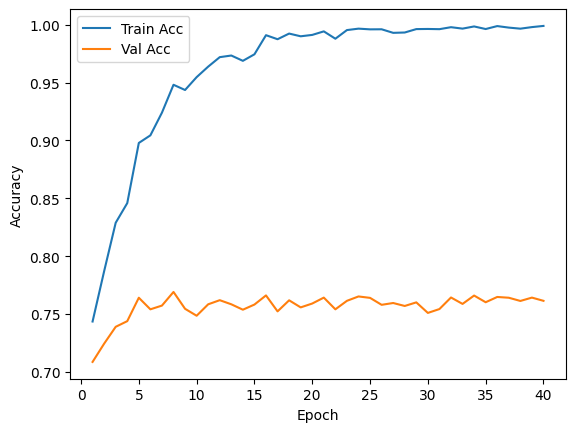

Final Train Acc: 99.8921568627451
Final Val Acc: 76.14444444444445


In [ ]:
x = np.arange(1, len(history["train_acc"]) + 1)

plt.figure()
plt.plot(x, history["train_acc"], label="Train Acc")
plt.plot(x, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print("Final Train Acc:", history["train_acc"][-1]*100)
print("Final Val Acc:", history["val_acc"][-1]*100)

In [ ]:
drive.mount('/content/drive')

SAVE_PATH = "/content/drive/MyDrive/quickdraw_mlp_model.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "hidden_sizes": HIDDEN_SIZES,
    "num_classes": num_classes
}, SAVE_PATH)

print("Model saved to:", SAVE_PATH)

Mounted at /content/drive
Model saved to: /content/drive/MyDrive/quickdraw_mlp_model.pth


In [ ]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    preds = []
    for x in loader:
        x = x.to(device)
        logits = model(x)
        preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)

test_predictions = predict(model, test_loader)

np.save("/content/drive/MyDrive/quickdraw_test_predictions.npy", test_predictions)

print("Test predictions saved.")
print("Prediction shape:", test_predictions.shape)

Test predictions saved.
Prediction shape: (15000,)
